# XGBoost Sepsis Prediction

My program uses the pre-processed CSV files created by Thomas' R pre-processing programs and restructures the experiments around a shared 90/10 split.

Because the preprocessing keeps **one row per patient**, I do **not** need patient-level grouped splitting, which I had originally for the XGBoost Model.  
`Patient_ID` is only used to keep the full and reduced datasets consitent to the **same train/test split**, which I then removed before modeling.

## Run Order
1. Flesh out and perform visual exploratory data analysis on:
   - `2.csv`
   - `1-to-1_full.csv`
   - `1-to-1_few.csv`
2. Keep the **same untouched 10% test set** across all dataset comparisons.
3. Compare three XGBoost setups:
   - **Baseline Full Dataset**: full training data, no undersampling
   - **Undersampled All Features**: undersampled balanced training data from `1-to-1_full.csv`
   - **Undersampled 11 Features**: undersampled balanced training data from `1-to-1_few.csv`
4. Summarize model performance on datsets with metrics:
   - Accuracy
   - Precision
   - Recall
   - F1
   - PR-AUC
   - Balanced Accuracy
   - Specificity
   - ROC-AUC
   - TN, FP, FN, TP

No imputation. XGBoost handles missing values directly.


from google.colab import drive
drive.mount("/content/drive", force_remount=True)

In [2]:
import warnings
warnings.filterwarnings("ignore")

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score,
    confusion_matrix,
    precision_recall_curve,
    roc_curve,
    balanced_accuracy_score
)

from xgboost import XGBClassifier

plt.rcParams["figure.figsize"] = (10, 6)
pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 200)


## 1. Load the datasets

PATH_2 = '/content/drive/My Drive/SepKnowsis/2.csv'
PATH_FULL = '/content/drive/My Drive/SepKnowsis/1-to-1_full.csv'
PATH_FEW = '/content/drive/My Drive/SepKnowsis/1-to-1_few.csv'

df2 = pd.read_csv(PATH_2)
df_full = pd.read_csv(PATH_FULL)
df_few = pd.read_csv(PATH_FEW)

print("2.csv shape:", df2.shape)
print("1-to-1_full.csv shape:", df_full.shape)
print("1-to-1_few.csv shape:", df_few.shape)


In [3]:
# Base path: go up one level, then into data folder
BASE_PATH = os.path.join("..", "R Analyzing and Preprocessing + Multilayer Perceptron")

PATH_2 = os.path.join(BASE_PATH, "2.csv")
PATH_FULL = os.path.join(BASE_PATH, "1-to-1_full.csv")
PATH_FEW = os.path.join(BASE_PATH, "1-to-1_few.csv")

# Load datasets
df2 = pd.read_csv(PATH_2)
df_full = pd.read_csv(PATH_FULL)
df_few = pd.read_csv(PATH_FEW)

# Confirm
print("2.csv shape:", df2.shape)
print("1-to-1_full.csv shape:", df_full.shape)
print("1-to-1_few.csv shape:", df_few.shape)

2.csv shape: (1552210, 48)
1-to-1_full.csv shape: (40336, 43)
1-to-1_few.csv shape: (40336, 13)


## 2. Helper functions

In [ ]:
TARGET = "SepsisLabel"
ID_COL = "Patient_ID"


# Summarizes dataset shape, class balance, and missingness
# -------------------------------------------------------------------------
def eda_summary(df, name):
    print(f"=== {name} ===")
    print("Shape:", df.shape)
    print("Columns:", df.columns.tolist())
    if TARGET in df.columns:
        counts = df[TARGET].value_counts(dropna=False).sort_index()
        props = df[TARGET].value_counts(normalize=True, dropna=False).sort_index()
        display(pd.DataFrame({"Count": counts, "Proportion": props}))
    if ID_COL in df.columns:
        print("Unique patients:", df[ID_COL].nunique())
    print()


def plot_class_balance(df, name):
    counts = df[TARGET].value_counts().sort_index()
    labels = ["No Sepsis (0)", "Sepsis (1)"]
    plt.figure(figsize=(6,4))
    plt.bar(labels, counts.values)
    plt.title(f"Class Distribution: {name}")
    plt.ylabel("Count")
    plt.show()


def missingness_table(df):
    out = (df.isna().mean() * 100).sort_values(ascending=False).reset_index()
    out.columns = ["Feature", "MissingPercent"]
    return out


def plot_missingness(df, name, top_n=None):
    miss = missingness_table(df)
    if top_n is not None:
        miss = miss.head(top_n)
    plt.figure(figsize=(10, max(4, 0.3 * len(miss))))
    plt.barh(miss["Feature"], miss["MissingPercent"])
    plt.gca().invert_yaxis()
    plt.xlabel("Percent Missing")
    plt.title(f"Missingness by Feature: {name}")
    plt.show()
# -------------------------------------------------------------------------


# Creates 90/10 train/test split to be used across datasets and
# undersamples yes sepsis records to balance sepsis vs non-sepsis cases
# -------------------------------------------------------------------------
def create_shared_split(df_full, df_few, test_size=0.10, random_state=42):
    full_train, full_test = train_test_split(
        df_full,
        test_size=test_size,
        random_state=random_state,
        stratify=df_full[TARGET]
    )
    full_train = full_train.reset_index(drop=True)
    full_test = full_test.reset_index(drop=True)

    if ID_COL in df_full.columns and ID_COL in df_few.columns:
        train_ids = set(full_train[ID_COL].tolist())
        test_ids = set(full_test[ID_COL].tolist())
        few_train = df_few[df_few[ID_COL].isin(train_ids)].copy()
        few_test = df_few[df_few[ID_COL].isin(test_ids)].copy()
    else:
        few_train, few_test = train_test_split(
            df_few,
            test_size=test_size,
            random_state=random_state,
            stratify=df_few[TARGET]
        )

    few_train = few_train.reset_index(drop=True)
    few_test = few_test.reset_index(drop=True)
    return full_train, full_test, few_train, few_test



def undersample_dataframe(input_df, target_col=TARGET, random_state=42):
    df_majority = input_df[input_df[target_col] == 0]
    df_minority = input_df[input_df[target_col] == 1]
    if len(df_minority) == 0:
        raise ValueError("No positive sepsis rows found for undersampling.")
    df_majority_down = df_majority.sample(n=len(df_minority), random_state=random_state)
    balanced = pd.concat([df_majority_down, df_minority], axis=0)
    return balanced.sample(frac=1, random_state=random_state).reset_index(drop=True)
# -------------------------------------------------------------------------


# Tuned XGBoost Model
# -------------------------------------------------------------------------
def build_xgb(random_state=42):
    return XGBClassifier(
        n_estimators=400,
        max_depth=4,
        learning_rate=0.05,
        subsample=0.8,
        colsample_bytree=0.8,
        min_child_weight=5,
        gamma=0.1,
        reg_alpha=1.0,
        reg_lambda=2.0,
        objective="binary:logistic",
        eval_metric="logloss",
        random_state=random_state,
        n_jobs=-1,
        missing=np.nan,
        tree_method="hist"
    )
# -------------------------------------------------------------------------


# Train the XGBoost model and generate performance metrics
# -------------------------------------------------------------------------
def evaluate_predictions(y_true, y_pred, y_prob):
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()
    specificity = tn / (tn + fp) if (tn + fp) > 0 else np.nan
    return {
        "Accuracy": accuracy_score(y_true, y_pred),
        "Precision": precision_score(y_true, y_pred, zero_division=0),
        "Recall": recall_score(y_true, y_pred, zero_division=0),
        "F1": f1_score(y_true, y_pred, zero_division=0),
        "BalancedAccuracy": balanced_accuracy_score(y_true, y_pred),
        "Specificity": specificity,
        "ROC_AUC": roc_auc_score(y_true, y_prob),
        "PR_AUC": average_precision_score(y_true, y_prob),
        "TN": tn,
        "FP": fp,
        "FN": fn,
        "TP": tp
    }



def fit_and_score(X_train, y_train, X_test, y_test, random_state=42):
    model = build_xgb(random_state=random_state)
    model.fit(X_train, y_train)
    train_pred = model.predict(X_train)
    train_prob = model.predict_proba(X_train)[:, 1]
    test_pred = model.predict(X_test)
    test_prob = model.predict_proba(X_test)[:, 1]
    train_metrics = evaluate_predictions(y_train, train_pred, train_prob)
    test_metrics = evaluate_predictions(y_test, test_pred, test_prob)
    return model, train_pred, train_prob, test_pred, test_prob, train_metrics, test_metrics



def show_split_summary(df_train, df_test, label):
    print(f"{label} train rows: {len(df_train):,}")
    print(f"{label} test rows: {len(df_test):,}")
    if ID_COL in df_train.columns:
        print(f"{label} unique train patients: {df_train[ID_COL].nunique():,}")
        print(f"{label} unique test patients: {df_test[ID_COL].nunique():,}")
# -------------------------------------------------------------------------


# Create visuals for metrics and features
# -------------------------------------------------------------------------
def plot_pr_curves(curve_dict, title="Precision-Recall Curves"):
    plt.figure(figsize=(8,6))
    for name, item in curve_dict.items():
        precision, recall, _ = precision_recall_curve(item["y_true"], item["y_prob"])
        plt.plot(recall, precision, label=f"{name} (PR-AUC={item['pr_auc']:.3f})")
    plt.xlabel("Recall")
    plt.ylabel("Precision")
    plt.title(title)
    plt.legend()
    plt.show()



def plot_roc_curves(curve_dict, title="ROC Curves"):
    plt.figure(figsize=(8,6))
    for name, item in curve_dict.items():
        fpr, tpr, _ = roc_curve(item["y_true"], item["y_prob"])
        plt.plot(fpr, tpr, label=f"{name} (ROC-AUC={item['roc_auc']:.3f})")
    plt.plot([0,1], [0,1], linestyle="--")
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title(title)
    plt.legend()
    plt.show()



def plot_confusion(cm_dict, title_prefix="Confusion Matrix"):
    n = len(cm_dict)
    fig, axes = plt.subplots(1, n, figsize=(6*n, 5))
    if n == 1:
        axes = [axes]
    for ax, (name, cm) in zip(axes, cm_dict.items()):
        ax.imshow(cm, cmap="Blues", aspect="auto")
        ax.set_title(f"{title_prefix}: {name}")
        ax.set_xlabel("Predicted")
        ax.set_ylabel("Actual")
        ax.set_xticks([0, 1])
        ax.set_yticks([0, 1])
        for i in range(2):
            for j in range(2):
                color = "white" if (i == 0 and j == 0) else "black"
                ax.text(j, i, int(cm[i, j]), ha="center", va="center", color=color)
    plt.tight_layout()
    plt.show()

def top_feature_importance(model, feature_names, top_n=15):
    fi = pd.Series(model.feature_importances_, index=feature_names).sort_values(ascending=False).head(top_n)
    return fi


## 3. Exploratory Data Analysis on `2.csv`

This file is the organized or appended version of the PhysioNet dataset, which was done through Thomas' pre-processing. I'm visualizing its class imbalance and missingness.


=== 2.csv ===
Shape: (1552210, 48)
Columns: ['V1', 'Hour', 'HR', 'O2Sat', 'Temp', 'SBP', 'MAP', 'DBP', 'Resp', 'EtCO2', 'BaseExcess', 'HCO3', 'FiO2', 'pH', 'PaCO2', 'SaO2', 'AST', 'BUN', 'Alkalinephos', 'Calcium', 'Chloride', 'Creatinine', 'Bilirubin_direct', 'Glucose', 'Lactate', 'Magnesium', 'Phosphate', 'Potassium', 'Bilirubin_total', 'TroponinI', 'Hct', 'Hgb', 'PTT', 'WBC', 'Fibrinogen', 'Platelets', 'Age', 'Gender', 'Unit1', 'Unit2', 'HospAdmTime', 'ICULOS', 'SepsisLabel', 'Patient_ID', 'Bilirubin_indirect', 'Male', 'Female', 'SepsisLabelChanged']


,Count,Proportion
SepsisLabel,,
0,1524294,0.982015
1,27916,0.017985


Unique patients: 40336



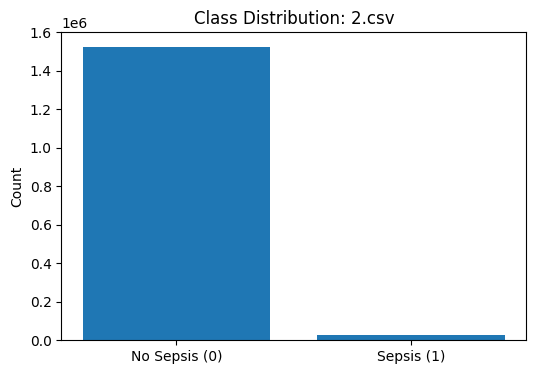

,Feature,MissingPercent
0,Bilirubin_indirect,99.829147
1,Bilirubin_direct,99.807371
2,Fibrinogen,99.340167
3,TroponinI,99.047745
4,Bilirubin_total,98.509158
5,Alkalinephos,98.393194
6,AST,98.377604
7,Lactate,97.329872
8,PTT,97.055875
9,SaO2,96.549372


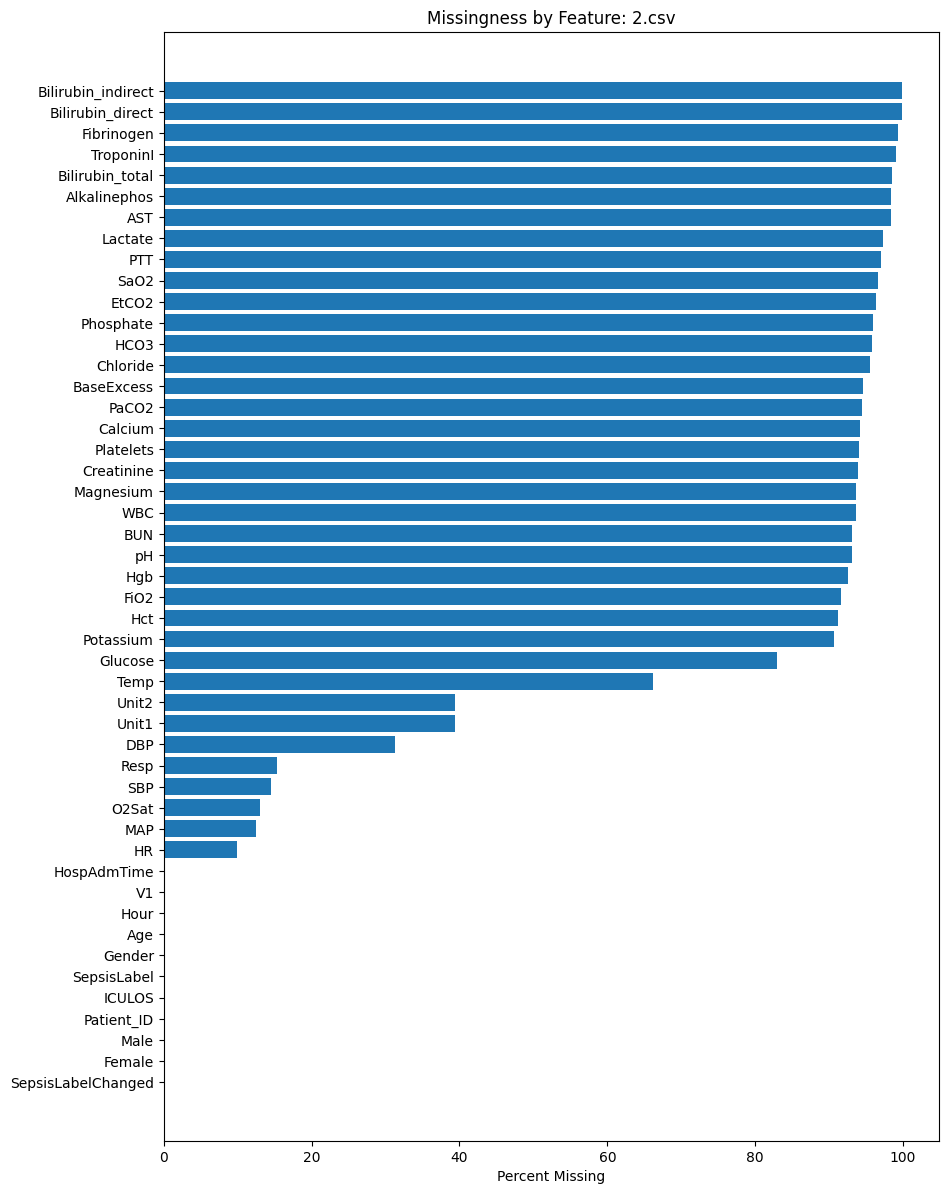

In [ ]:
eda_summary(df2, "2.csv")
plot_class_balance(df2, "2.csv")
missing_2 = missingness_table(df2)
display(missing_2)
plot_missingness(df2, "2.csv")


## 4. Exploratory Data Analysis on `1-to-1_full.csv`

This dataset contains one aggregated row per patient using the full feature set.


=== 1-to-1_full.csv ===
Shape: (40336, 43)
Columns: ['HR', 'O2Sat', 'Temp', 'SBP', 'MAP', 'DBP', 'Resp', 'EtCO2', 'BaseExcess', 'HCO3', 'FiO2', 'pH', 'PaCO2', 'SaO2', 'AST', 'BUN', 'Alkalinephos', 'Calcium', 'Chloride', 'Creatinine', 'Bilirubin_direct', 'Glucose', 'Lactate', 'Magnesium', 'Phosphate', 'Potassium', 'Bilirubin_total', 'TroponinI', 'Hct', 'Hgb', 'PTT', 'WBC', 'Fibrinogen', 'Platelets', 'Age', 'Unit1', 'Unit2', 'HospAdmTime', 'ICULOS', 'SepsisLabel', 'Patient_ID', 'Male', 'Female']


,Count,Proportion
SepsisLabel,,
0,37404,0.927311
1,2932,0.072689


Unique patients: 40336



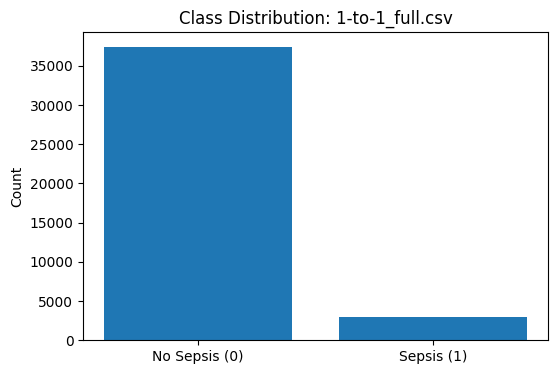

,Feature,MissingPercent
0,Bilirubin_direct,99.883479
1,TroponinI,99.702499
2,Bilirubin_total,99.216581
3,Alkalinephos,99.072789
4,AST,99.060393
5,EtCO2,98.837267
6,Fibrinogen,98.604225
7,Phosphate,97.860472
8,Calcium,97.059699
9,Lactate,96.891115


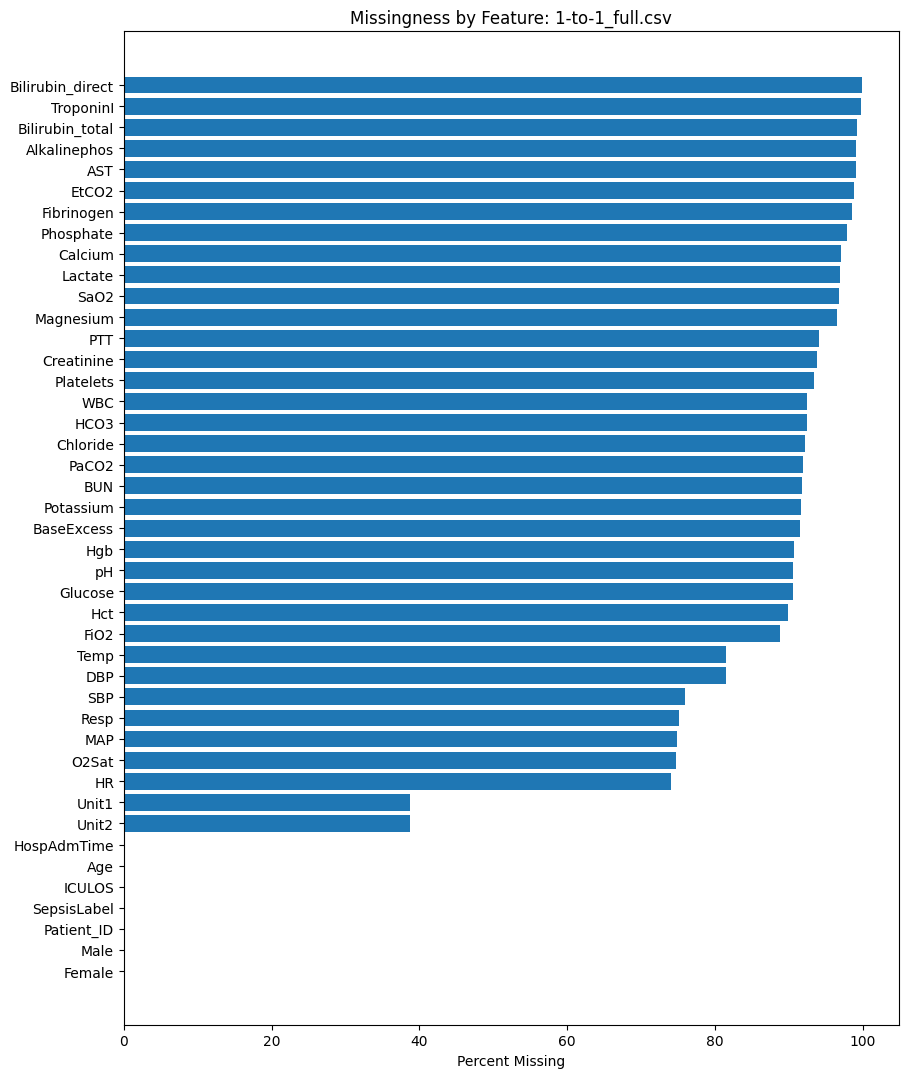

In [ ]:
eda_summary(df_full, "1-to-1_full.csv")
plot_class_balance(df_full, "1-to-1_full.csv")
missing_full = missingness_table(df_full)
display(missing_full)
plot_missingness(df_full, "1-to-1_full.csv")


## 5. Exploratory Data Analysis on `1-to-1_few.csv`

This dataset contains one aggregated row per patient using the reduced feature set.  
After excluding `Patient_ID` and the target, this leaves 11 predictors, with Gender considered one feature, but `Male` and `Female` are kept as separate columns in the file.


=== 1-to-1_few.csv ===
Shape: (40336, 13)
Columns: ['HR', 'O2Sat', 'Temp', 'SBP', 'MAP', 'DBP', 'Resp', 'EtCO2', 'Age', 'SepsisLabel', 'Patient_ID', 'Male', 'Female']


,Count,Proportion
SepsisLabel,,
0,37404,0.927311
1,2932,0.072689


Unique patients: 40336



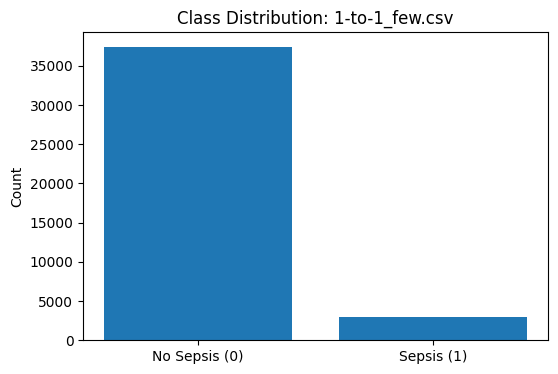

,Feature,MissingPercent
0,EtCO2,98.837267
1,Temp,81.537584
2,DBP,81.478084
3,SBP,75.932170
4,Resp,75.119000
5,MAP,74.789270
6,O2Sat,74.704978
7,HR,74.038080
8,Age,0.000000
9,SepsisLabel,0.000000


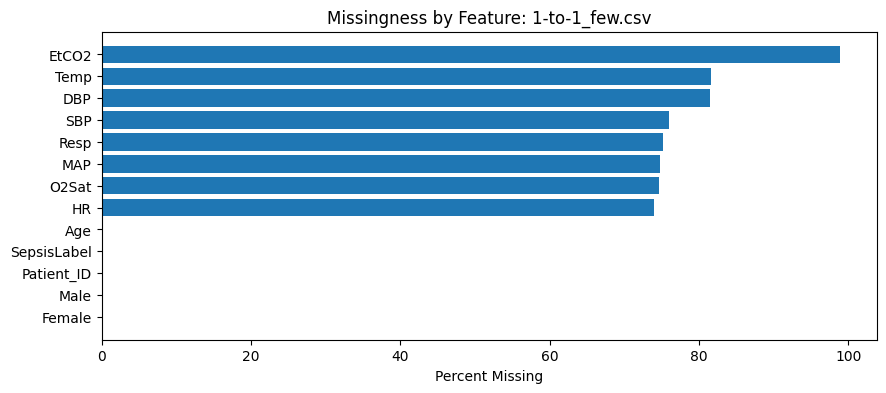

In [ ]:
eda_summary(df_few, "1-to-1_few.csv")
plot_class_balance(df_few, "1-to-1_few.csv")
missing_few = missingness_table(df_few)
display(missing_few)
plot_missingness(df_few, "1-to-1_few.csv")


## 6. Create 90/10 split from the full dataset

Since the pre-processing leaves **one row per patient**, I can use a 90/10 train test split without having to group by `Patient_ID`.

The split is defined once using `1-to-1_full.csv`.  
Then, if `Patient_ID` is present in both files, it is used only to align the reduced dataset to the same train/test rows before being removed from modeling.

This keeps the ** same untouched test set** across the three experiments.


In [ ]:
df_full_train, df_full_test, df_few_train, df_few_test = create_shared_split(
    df_full,
    df_few,
    test_size=0.10,
    random_state=42
)

show_split_summary(df_full_train, df_full_test, "Full dataset split")
show_split_summary(df_few_train, df_few_test, "Few dataset split")

print("\nFull training label counts:")
display(df_full_train[TARGET].value_counts())
print("Full test label counts:")
display(df_full_test[TARGET].value_counts())


Full dataset split train rows: 36,302
Full dataset split test rows: 4,034
Full dataset split unique train patients: 36,302
Full dataset split unique test patients: 4,034
Few dataset split train rows: 36,302
Few dataset split test rows: 4,034
Few dataset split unique train patients: 36,302
Few dataset split unique test patients: 4,034

Full training label counts:


,count
SepsisLabel,
0,33663
1,2639


Full test label counts:


,count
SepsisLabel,
0,3741
1,293


## 7. Datasets Model Features

`Patient_ID` is removed from both datasets before training.


In [ ]:
full_features = [c for c in df_full.columns if c not in [TARGET, ID_COL]]
few_features = [c for c in df_few.columns if c not in [TARGET, ID_COL]]

print("Number of full predictors:", len(full_features))
print("Full predictors:", full_features)
print("\nNumber of reduced predictors:", len(few_features))
print("Reduced predictors:", few_features)


Number of full predictors: 41
Full predictors: ['HR', 'O2Sat', 'Temp', 'SBP', 'MAP', 'DBP', 'Resp', 'EtCO2', 'BaseExcess', 'HCO3', 'FiO2', 'pH', 'PaCO2', 'SaO2', 'AST', 'BUN', 'Alkalinephos', 'Calcium', 'Chloride', 'Creatinine', 'Bilirubin_direct', 'Glucose', 'Lactate', 'Magnesium', 'Phosphate', 'Potassium', 'Bilirubin_total', 'TroponinI', 'Hct', 'Hgb', 'PTT', 'WBC', 'Fibrinogen', 'Platelets', 'Age', 'Unit1', 'Unit2', 'HospAdmTime', 'ICULOS', 'Male', 'Female']

Number of reduced predictors: 11
Reduced predictors: ['HR', 'O2Sat', 'Temp', 'SBP', 'MAP', 'DBP', 'Resp', 'EtCO2', 'Age', 'Male', 'Female']


## 8. Baseline: Full dataset, no undersampling

In [ ]:
X_train_base = df_full_train[full_features]
y_train_base = df_full_train[TARGET]
X_test_base = df_full_test[full_features]
y_test_base = df_full_test[TARGET]

(
    baseline_model,
    baseline_train_pred,
    baseline_train_prob,
    baseline_test_pred,
    baseline_test_prob,
    baseline_train_metrics,
    baseline_test_metrics
) = fit_and_score(X_train_base, y_train_base, X_test_base, y_test_base, random_state=42)

baseline_metrics_df = pd.DataFrame([baseline_train_metrics, baseline_test_metrics], index=["Baseline Train", "Baseline Test"])
display(baseline_metrics_df)


,Accuracy,Precision,Recall,F1,BalancedAccuracy,Specificity,ROC_AUC,PR_AUC,TN,FP,FN,TP
Baseline Train,0.984271,0.971285,0.807503,0.881854,0.902816,0.998129,0.970144,0.909077,33600,63,508,2131
Baseline Test,0.980416,0.961207,0.761092,0.849524,0.879343,0.997594,0.927178,0.842451,3732,9,70,223


## 9. Undersampled, balanced full dataset

The training portion of `1-to-1_full.csv` is balanced by matching the number of no-sepsis rows to the number of sepsis rows, while keeping all sepsis rows.


In [ ]:
df_full_train_bal = undersample_dataframe(df_full_train, target_col=TARGET, random_state=42)

print("Balanced full training label counts:")
display(df_full_train_bal[TARGET].value_counts())

X_train_full_bal = df_full_train_bal[full_features]
y_train_full_bal = df_full_train_bal[TARGET]
X_test_full_bal = df_full_test[full_features]
y_test_full_bal = df_full_test[TARGET]

(
    under_full_model,
    under_full_train_pred,
    under_full_train_prob,
    under_full_test_pred,
    under_full_test_prob,
    under_full_train_metrics,
    under_full_test_metrics
) = fit_and_score(X_train_full_bal, y_train_full_bal, X_test_full_bal, y_test_full_bal, random_state=42)

under_full_metrics_df = pd.DataFrame([under_full_train_metrics, under_full_test_metrics], index=["Under-sampled All Features​ Train", "Under-sampled All Features​ Test"])
display(under_full_metrics_df)


Balanced full training label counts:


,count
SepsisLabel,
0,2639
1,2639


,Accuracy,Precision,Recall,F1,BalancedAccuracy,Specificity,ROC_AUC,PR_AUC,TN,FP,FN,TP
Under-sampled All Features​ Train,0.929519,0.989633,0.868132,0.924909,0.929519,0.990906,0.974631,0.980519,2615,24,348,2291
Under-sampled All Features​ Test,0.960337,0.697329,0.802048,0.746032,0.887391,0.972735,0.926751,0.841248,3639,102,58,235


## 10. Undersampled balanced 11 feature dataset (`few`)

The training portion of `1-to-1_few.csv` is balanced in the same way, while the **same fixed test patients** are used for evaluation.


In [ ]:
df_few_train_bal = undersample_dataframe(df_few_train, target_col=TARGET, random_state=42)

print("Balanced few training label counts:")
display(df_few_train_bal[TARGET].value_counts())

X_train_few_bal = df_few_train_bal[few_features]
y_train_few_bal = df_few_train_bal[TARGET]
X_test_few_bal = df_few_test[few_features]
y_test_few_bal = df_few_test[TARGET]

(
    under_few_model,
    under_few_train_pred,
    under_few_train_prob,
    under_few_test_pred,
    under_few_test_prob,
    under_few_train_metrics,
    under_few_test_metrics
) = fit_and_score(X_train_few_bal, y_train_few_bal, X_test_few_bal, y_test_few_bal, random_state=42)

under_few_metrics_df = pd.DataFrame([under_few_train_metrics, under_few_test_metrics], index=["Under-sampled 11 Features​ Train", "Under-sampled 11 Features​ Test"])
display(under_few_metrics_df)


Balanced few training label counts:


,count
SepsisLabel,
0,2639
1,2639


,Accuracy,Precision,Recall,F1,BalancedAccuracy,Specificity,ROC_AUC,PR_AUC,TN,FP,FN,TP
Under-sampled 11 Features​ Train,0.874953,0.938026,0.802956,0.865251,0.874953,0.946950,0.918759,0.939730,2499,140,520,2119
Under-sampled 11 Features​ Test,0.894398,0.382301,0.737201,0.503497,0.821955,0.906709,0.853296,0.589655,3392,349,77,216


## 11. 3 Tests Comparison Table

This table compares the three experimental setups on the **same untouched 10% test patients**.


In [ ]:
main_results = pd.DataFrame(
    [
        baseline_test_metrics,
        under_full_test_metrics,
        under_few_test_metrics
    ],
    index=[
        "Baseline Full Dataset",
        "Under-sampled All Features​",
        "Under-sampled 11 Features​"
    ]
)

display(main_results)


,Accuracy,Precision,Recall,F1,BalancedAccuracy,Specificity,ROC_AUC,PR_AUC,TN,FP,FN,TP
Baseline Full Dataset,0.980416,0.961207,0.761092,0.849524,0.879343,0.997594,0.927178,0.842451,3732,9,70,223
Under-sampled All Features​,0.960337,0.697329,0.802048,0.746032,0.887391,0.972735,0.926751,0.841248,3639,102,58,235
Under-sampled 11 Features​,0.894398,0.382301,0.737201,0.503497,0.821955,0.906709,0.853296,0.589655,3392,349,77,216


## 12. PR-AUC and ROC-AUC Curves

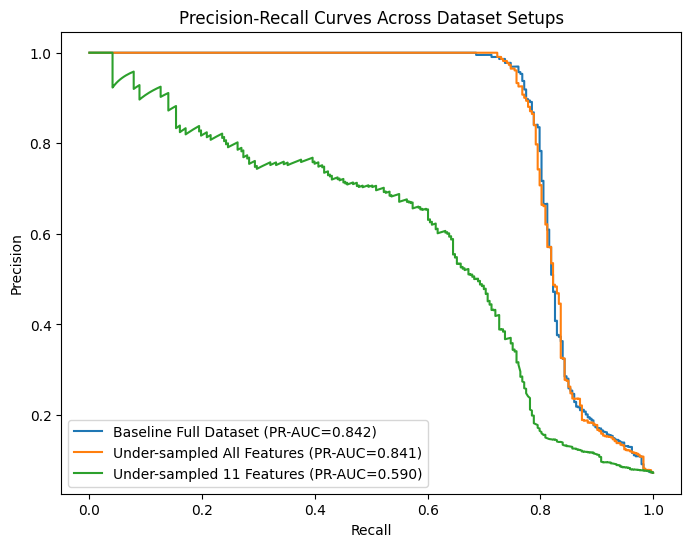

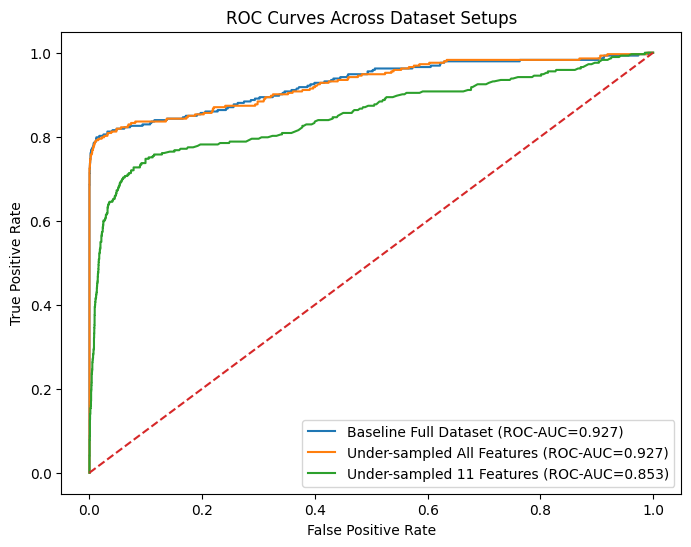

In [ ]:
curve_store = {
    "Baseline Full Dataset": {
        "y_true": np.array(y_test_base),
        "y_prob": np.array(baseline_test_prob),
        "pr_auc": baseline_test_metrics["PR_AUC"],
        "roc_auc": baseline_test_metrics["ROC_AUC"]
    },
    "Under-sampled All Features​": {
        "y_true": np.array(y_test_full_bal),
        "y_prob": np.array(under_full_test_prob),
        "pr_auc": under_full_test_metrics["PR_AUC"],
        "roc_auc": under_full_test_metrics["ROC_AUC"]
    },
    "Under-sampled 11 Features​": {
        "y_true": np.array(y_test_few_bal),
        "y_prob": np.array(under_few_test_prob),
        "pr_auc": under_few_test_metrics["PR_AUC"],
        "roc_auc": under_few_test_metrics["ROC_AUC"]
    }
}

plot_pr_curves(curve_store, title="Precision-Recall Curves Across Dataset Setups")
plot_roc_curves(curve_store, title="ROC Curves Across Dataset Setups")


## 13. Confusion Matrices

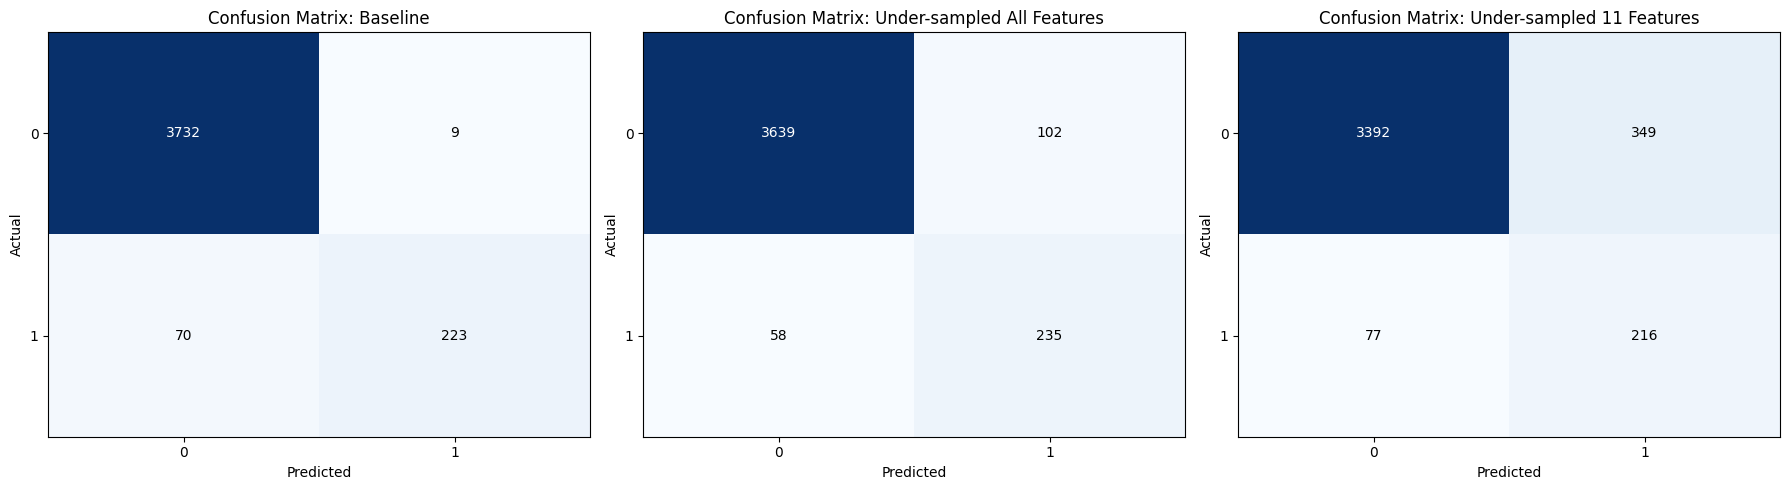

In [ ]:
conf_mats = {
    "Baseline": confusion_matrix(y_test_base, baseline_test_pred),
    "Under-sampled All Features​": confusion_matrix(y_test_full_bal, under_full_test_pred),
    "Under-sampled 11 Features​": confusion_matrix(y_test_few_bal, under_few_test_pred)
}
plot_confusion(conf_mats, title_prefix="Confusion Matrix")


## 14. Feature Importance

Top feature importance values are shown for each trained model.


,Baseline
ICULOS,0.471937
Resp,0.052211
FiO2,0.045219
Temp,0.041981
MAP,0.035977
Hct,0.028130
Unit2,0.021984
pH,0.021231
HCO3,0.020936
Chloride,0.020634


,Under-sampled All Features​
ICULOS,0.421930
FiO2,0.068400
HR,0.056687
MAP,0.037788
Temp,0.036003
Hct,0.034599
Chloride,0.027070
Resp,0.026069
Unit2,0.021488
BaseExcess,0.018565


,Under-sampled 11 Features​
HR,0.252876
MAP,0.206712
Temp,0.123587
O2Sat,0.109694
Resp,0.098298
EtCO2,0.072173
DBP,0.036396
SBP,0.030356
Female,0.027248
Age,0.022568


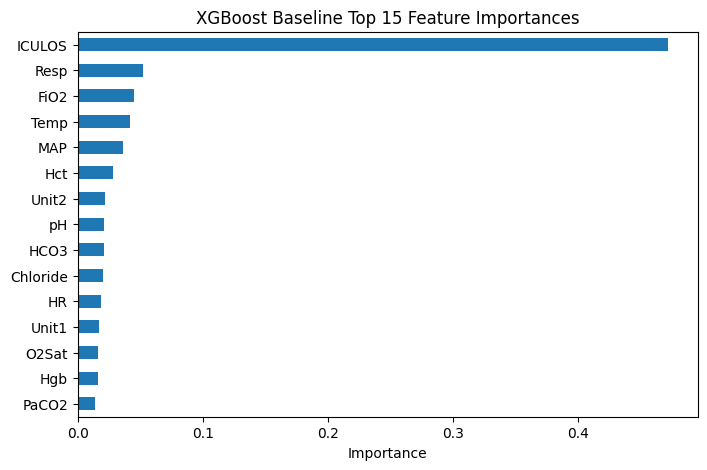

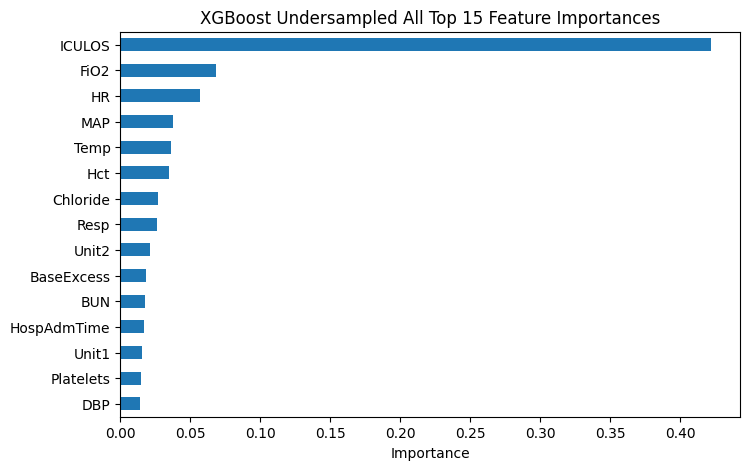

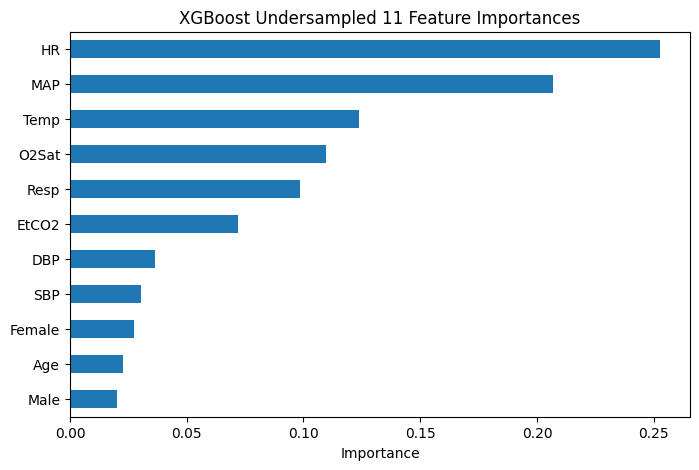

In [ ]:
fi_baseline = top_feature_importance(baseline_model, full_features, top_n=15)
fi_under_full = top_feature_importance(under_full_model, full_features, top_n=15)
fi_under_few = top_feature_importance(under_few_model, few_features, top_n=15)

display(pd.DataFrame({"Baseline": fi_baseline}))
display(pd.DataFrame({"Under-sampled All Features​": fi_under_full}))
display(pd.DataFrame({"Under-sampled 11 Features​": fi_under_few}))

for title, fi in [
    ("XGBoost Baseline Top 15 Feature Importances", fi_baseline),
    ("XGBoost Undersampled All Top 15 Feature Importances", fi_under_full),
    ("XGBoost Undersampled 11 Feature Importances", fi_under_few)
]:
    plt.figure(figsize=(8,5))
    fi.sort_values().plot(kind="barh")
    plt.title(title)
    plt.xlabel("Importance")
    plt.show()


## 15. Correlation Matrix

A correlation heatmap is shown for the full feature dataset predictors to help interpret feature importance.


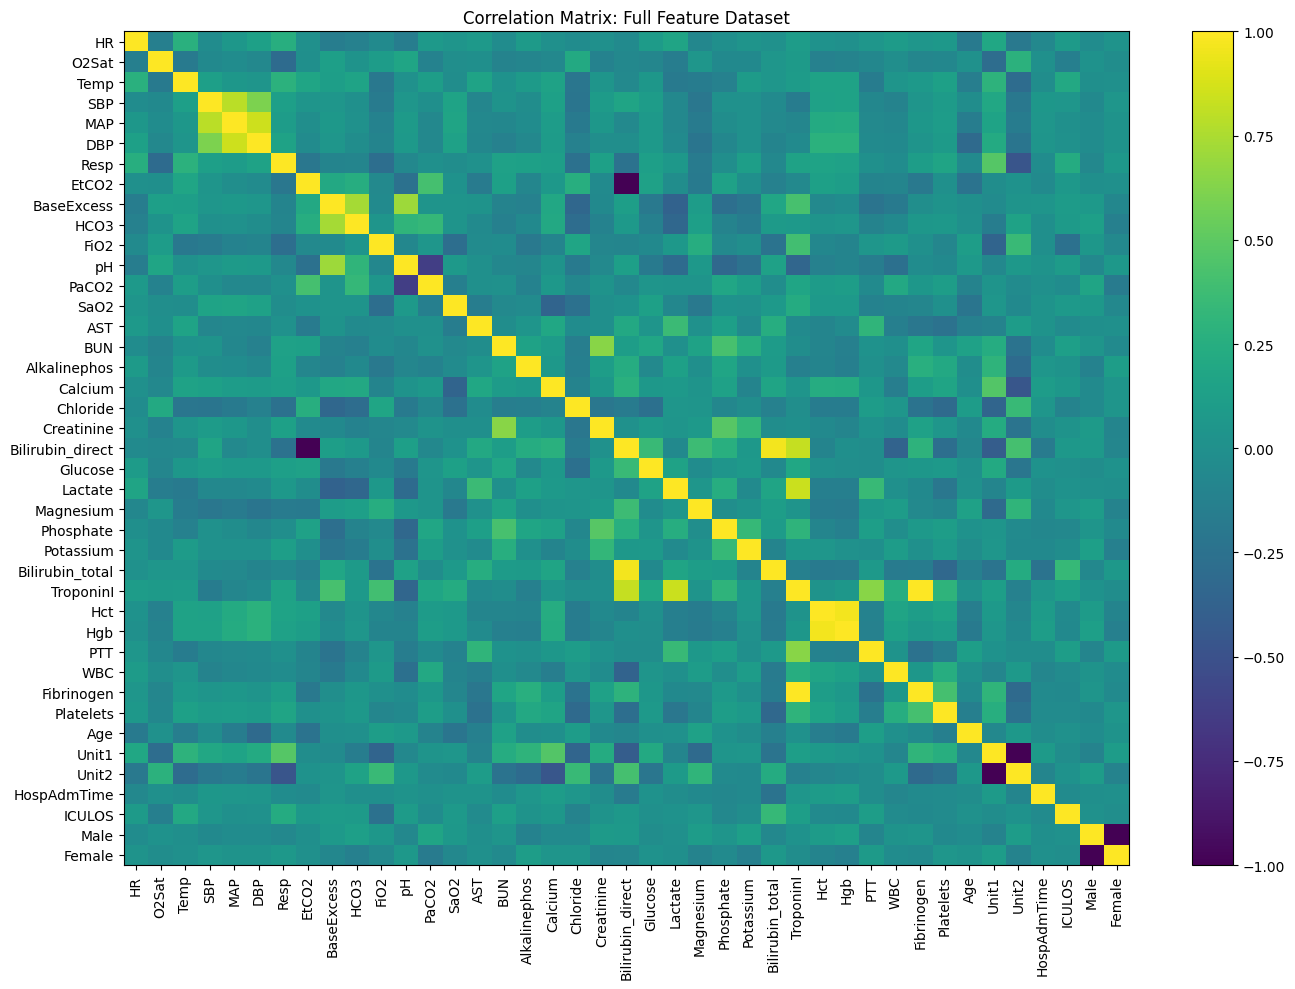

In [ ]:
corr_df = df_full[full_features].corr(numeric_only=True)

plt.figure(figsize=(14, 10))
plt.imshow(corr_df, aspect="auto")
plt.colorbar()
plt.xticks(range(len(corr_df.columns)), corr_df.columns, rotation=90)
plt.yticks(range(len(corr_df.columns)), corr_df.columns)
plt.title("Correlation Matrix: Full Feature Dataset")
plt.tight_layout()
plt.show()


## 16. Compressed Final Results

This table keeps the main performance metrics for comparing the three dataset experiments.


In [ ]:
compact_results = main_results[[
    "Accuracy", "Precision", "Recall", "F1", "BalancedAccuracy",
    "Specificity", "ROC_AUC", "PR_AUC", "TN", "FP", "FN", "TP"
]].copy()

display(compact_results)


,Accuracy,Precision,Recall,F1,BalancedAccuracy,Specificity,ROC_AUC,PR_AUC,TN,FP,FN,TP
Baseline Full Dataset,0.980416,0.961207,0.761092,0.849524,0.879343,0.997594,0.927178,0.842451,3732,9,70,223
Under-sampled All Features​,0.960337,0.697329,0.802048,0.746032,0.887391,0.972735,0.926751,0.841248,3639,102,58,235
Under-sampled 11 Features​,0.894398,0.382301,0.737201,0.503497,0.821955,0.906709,0.853296,0.589655,3392,349,77,216
